#  Обнаружение объектов

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html
* https://pyimagesearch.com/2021/11/01/training-an-object-detector-from-scratch-in-pytorch/
* https://pyimagesearch.com/2021/08/02/pytorch-object-detection-with-pre-trained-networks/

In [1]:
# ИСПОЛЬЗУЕМЫЕ БИБЛИОТЕКИ
import os
import random
import warnings
import zipfile
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from torchvision.ops import batched_nms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Задачи для совместного разбора

1\. Рассмотрите простейшую архитектуру для решения задачи object detection и процесс настройки модели.

In [2]:
class TinyYOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=20): # S - сетка(7x7), B - количество предсказываемых ограничивающих рамок в клетке, С - количество классов
        super().__init__()
        self.S = S
        self.B = B
        self.C = C
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1), # вместо вывода нуля для отрицательных входов, Leaky ReLU выводит значение, умноженное на небольшую константу («утечка»).
                               # Это гарантирует, что нейрон никогда не будет иметь нулевой градиент, что позволяет ему восстанавливаться и продолжать обучение.
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool2d((S, S))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * S * S, 4096),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(4096, S * S * (B * 5 + C))
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x.view(-1, self.S, self.S, self.B * 5 + self.C)

In [3]:
def decode_yolo_output(pred, S=7, B=2, C=20, conf_threshold=0.5, nms_threshold=0.4):
    """Декодирует демонстрационный выход TinyYOLOv1.

    Модель в этом разделе не обучается, поэтому функция нужна только для
    демонстрации структуры выхода. Sigmoid/softmax переводят сырые logits
    в допустимые диапазоны, а batched_nms выполняет NMS отдельно по классам.
    """
    pred = pred.squeeze(0)
    detections = []

    class_probs = torch.softmax(pred[:, :, B * 5:], dim=-1)

    for i in range(S):
        for j in range(S):
            for b in range(B):
                offset = b * 5
                x_cell, y_cell, w_rel, h_rel, conf = torch.sigmoid(
                    pred[i, j, offset:offset + 5]
                )

                x_center = (j + float(x_cell)) / S
                y_center = (i + float(y_cell)) / S
                w = float(w_rel)
                h = float(h_rel)

                class_id = int(class_probs[i, j].argmax())
                class_conf = float(conf * class_probs[i, j, class_id])
                if class_conf < conf_threshold:
                    continue

                x1 = max(0.0, min(1.0, x_center - w / 2))
                y1 = max(0.0, min(1.0, y_center - h / 2))
                x2 = max(0.0, min(1.0, x_center + w / 2))
                y2 = max(0.0, min(1.0, y_center + h / 2))
                if x2 <= x1 or y2 <= y1:
                    continue

                detections.append([class_id, class_conf, x1, y1, x2, y2])

    if not detections:
        return []

    det = torch.tensor(detections, dtype=torch.float32)
    keep = batched_nms(det[:, 2:6], det[:, 1], det[:, 0].long(), nms_threshold)
    return det[keep].tolist()


In [4]:
model = TinyYOLOv1(S=7, B=2, C=20); model

TinyYOLOv1(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), paddin

In [5]:
img = torch.randn(1, 3, 448, 448)  # YOLOv1 использует 448x448
print('Форма входа:', tuple(img.shape))


Форма входа: (1, 3, 448, 448)


In [6]:
with torch.no_grad():
        output = model(img)
output.shape

torch.Size([1, 7, 7, 30])

In [7]:
print('Первые 10 выходов ячейки (3, 3):')
print(output[0, 3, 3, :10].detach().cpu().numpy().round(4))


Первые 10 выходов ячейки (3, 3):
[ 0.1761 -0.1471  0.0085 -0.0171  0.1166 -0.0798  0.035  -0.1182  0.0009
 -0.0914]


In [8]:
detections = decode_yolo_output(
    output, S=7, B=2, C=20,
    conf_threshold=0.20,
    nms_threshold=0.4,
)
print('Количество демонстрационных детекций:', len(detections))


Количество демонстрационных детекций: 0


In [9]:
if not detections:
    print('У случайно инициализированной модели нет детекций выше порога — это нормально.')
else:
    for det in detections[:5]:
        cls_id, conf, x1, y1, x2, y2 = det
        print(f'Класс {int(cls_id)}: conf={conf:.3f}, bbox=({x1:.3f}, {y1:.3f}, {x2:.3f}, {y2:.3f})')


У случайно инициализированной модели нет детекций выше порога — это нормально.


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Напишите функцию `parse_xml`, которая читает xml-файл с разметкой изображения из архива `animals.zip` и возвращает словарь, содержащий три ключа:
```
{
        "raw": # словарь с ключами xmin, ymin, xmax, ymax
        "scaled": # словарь с ключами xmin, ymin, xmax, ymax
        "obj_name": # строка
}
```
В этом словаре `row` - абсолютные значения координат вершин bounding box, а `scaled` - относительные (нормированные на ширину и высоту изображения). Примените функцию к файлу `cat.0.xml` и выведите результат на экран.


- [ ] Проверено на семинаре

In [10]:
def _xml_root(xml_source):
    """Возвращает корень Pascal VOC XML из пути, bytes или file-like объекта."""
    if isinstance(xml_source, (str, os.PathLike, Path)):
        return ET.parse(xml_source).getroot()
    if isinstance(xml_source, (bytes, bytearray)):
        return ET.fromstring(xml_source)
    # zipfile.open(), BytesIO и другие file-like объекты
    return ET.parse(xml_source).getroot()


def _pascal_number(text):
    """Читает и целые, и дробные координаты из Pascal VOC XML."""
    value = float(text)
    if abs(value - round(value)) < 1e-9:
        return int(round(value))
    return round(value, 4)


def parse_xml(xml_file_path):
    """Читает Pascal VOC XML и возвращает ровно словарь из условия задачи."""
    root = _xml_root(xml_file_path)

    size = root.find('size')
    if size is None:
        raise ValueError('В XML отсутствует секция <size>')
    width = float(size.findtext('width'))
    height = float(size.findtext('height'))
    if width <= 0 or height <= 0:
        raise ValueError(f'Некорректный размер изображения: {width}x{height}')

    obj = root.find('object')
    if obj is None:
        raise ValueError('В XML отсутствует секция <object>')

    obj_name = (obj.findtext('name') or '').strip().lower()
    box = obj.find('bndbox')
    if box is None:
        raise ValueError('В XML отсутствует секция <bndbox>')

    xmin_f = float(box.findtext('xmin'))
    ymin_f = float(box.findtext('ymin'))
    xmax_f = float(box.findtext('xmax'))
    ymax_f = float(box.findtext('ymax'))

    xmin = _pascal_number(box.findtext('xmin'))
    ymin = _pascal_number(box.findtext('ymin'))
    xmax = _pascal_number(box.findtext('xmax'))
    ymax = _pascal_number(box.findtext('ymax'))

    return {
        'raw': {
            'xmin': xmin, 'ymin': ymin,
            'xmax': xmax, 'ymax': ymax,
        },
        'scaled': {
            'xmin': xmin_f / width,
            'ymin': ymin_f / height,
            'xmax': xmax_f / width,
            'ymax': ymax_f / height,
        },
        'obj_name': obj_name,
    }


In [11]:
def find_asirra_dir():
    """Ищет распакованную папку, где cat.0.jpg и cat.0.xml лежат рядом."""
    exact_candidates = [
        Path('labs') / 'Asirra_ cat vs dogs',
        Path.cwd() / 'labs' / 'Asirra_ cat vs dogs',
        Path('/content/labs') / 'Asirra_ cat vs dogs',
    ]
    for p in exact_candidates:
        if (p / 'cat.0.jpg').is_file() and (p / 'cat.0.xml').is_file():
            return p.resolve()

    search_roots = [Path.cwd(), Path.cwd() / 'labs', Path('/content'), Path('/content/labs')]
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        try:
            for xml_path in root.rglob('cat.0.xml'):
                folder = xml_path.parent.resolve()
                if folder in seen:
                    continue
                seen.add(folder)
                if (folder / 'cat.0.jpg').is_file():
                    return folder
        except (PermissionError, OSError):
            pass

    raise FileNotFoundError(
        "Не найдена папка с cat.0.jpg и cat.0.xml. "
        "Ожидаемый путь: labs/Asirra_ cat vs dogs"
    )


DATA_DIR = find_asirra_dir()
xml_files = sorted(DATA_DIR.glob('*.xml'))
image_files = sorted(DATA_DIR.glob('*.jpg'))
print('Папка датасета:', DATA_DIR)
print('XML-аннотаций:', len(xml_files))
print('JPG-изображений:', len(image_files))
print('cat.0.jpg:', (DATA_DIR / 'cat.0.jpg').is_file())
print('cat.0.xml:', (DATA_DIR / 'cat.0.xml').is_file())


Папка датасета: /home/crazy/work/labs/Asirra_ cat vs dogs
XML-аннотаций: 1100
JPG-изображений: 1100
cat.0.jpg: True
cat.0.xml: True


In [12]:
cat_xml_path = DATA_DIR / 'cat.0.xml'
result = parse_xml(cat_xml_path)
print('Файл:', cat_xml_path)
print(result)


Файл: /home/crazy/work/labs/Asirra_ cat vs dogs/cat.0.xml
{'raw': {'xmin': 126, 'ymin': 83, 'xmax': 354, 'ymax': 243}, 'scaled': {'xmin': 0.252, 'ymin': 0.22192513368983957, 'xmax': 0.708, 'ymax': 0.6497326203208557}, 'obj_name': 'cat'}


<p class="task" id="2"></p>

2\. Опишите датасет `AnimalDetectionDataset` на основе архива `animals.zip`. Реализуйте `__getitem__` таким образом, чтобы он возвращал три элемента: тензор с изображением, словарь с координатами bounding box и метку объекта. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений, преобразование для метки объекта (для кодирования) и флаг, показывающий, нужно ли возвращать исходные или нормированные координаты bounding box.

- [ ] Проверено на семинаре

In [13]:
def encode_animal_label(label_name):
    label = str(label_name).strip().lower()
    mapping = {'cat': 0, 'dog': 1}
    if label not in mapping:
        raise ValueError(f'Неизвестный класс: {label_name}')
    return mapping[label]


def class_from_filename(filename):
    """Asirra кодирует класс прямо в имени cat.* / dog.*."""
    name = Path(filename).name.lower()
    if name.startswith('cat.'):
        return 'cat'
    if name.startswith('dog.'):
        return 'dog'
    return None


class AnimalDetectionDataset(Dataset):
    """Dataset для распакованной Pascal VOC папки: image.jpg и image.xml лежат рядом.

    Для Asirra имя файла cat.* / dog.* используется как дополнительная проверка
    класса. Если XML конфликтует с именем файла, для классификации берётся класс
    из имени, а конфликт сохраняется в ``label_conflicts`` и явно выводится.
    Bounding box всегда читается из XML.
    """
    def __init__(self, root=DATA_DIR, transforms=None, target_transform=None,
                 return_scaled=True, prefer_filename_label=True):
        self.root = Path(root)
        self.transforms = transforms
        self.target_transform = target_transform
        self.return_scaled = bool(return_scaled)
        self.prefer_filename_label = bool(prefer_filename_label)

        if not self.root.is_dir():
            raise FileNotFoundError(f'Папка датасета не найдена: {self.root}')

        self.samples = []
        self.label_conflicts = []

        for xml_path in sorted(self.root.glob('*.xml')):
            stem = xml_path.stem
            image_path = None
            for ext in ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'):
                candidate = self.root / f'{stem}{ext}'
                if candidate.is_file():
                    image_path = candidate
                    break
            if image_path is None:
                continue

            ann = parse_xml(xml_path)
            xml_label = ann['obj_name'].lower()
            filename_label = class_from_filename(image_path.name)

            if filename_label in ('cat', 'dog') and xml_label in ('cat', 'dog') and filename_label != xml_label:
                self.label_conflicts.append({
                    'filename': image_path.name,
                    'xml_label': xml_label,
                    'filename_label': filename_label,
                })

            if self.prefer_filename_label and filename_label in ('cat', 'dog'):
                effective_label = filename_label
            else:
                effective_label = xml_label

            if effective_label not in ('cat', 'dog'):
                continue

            self.samples.append({
                'image_path': image_path,
                'xml_path': xml_path,
                'filename': image_path.name,
                'obj_name': effective_label,
                'xml_obj_name': xml_label,
            })

        if not self.samples:
            raise RuntimeError(f'В {self.root} не найдено ни одной пары JPG/XML')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image = Image.open(sample['image_path']).convert('RGB')
        ann = parse_xml(sample['xml_path'])

        if self.transforms is not None:
            image_tensor = self.transforms(image)
        else:
            image_tensor = transforms.ToTensor()(image)

        bbox = dict(ann['scaled'] if self.return_scaled else ann['raw'])

        label = sample['obj_name']
        if self.target_transform is not None:
            label = self.target_transform(label)

        return image_tensor, bbox, label

    def label_name(self, index):
        return self.samples[index]['obj_name']


In [14]:
dataset = AnimalDetectionDataset(
    root=DATA_DIR,
    transforms=None,
    target_transform=encode_animal_label,
    return_scaled=True,
)

print('Размер датасета:', len(dataset))
print('Конфликтов XML-label ↔ filename-label:', len(dataset.label_conflicts))
if dataset.label_conflicts:
    print('Первые конфликты (для обучения исправляются по имени cat.* / dog.*):')
    for item in dataset.label_conflicts[:5]:
        print(' ', item)

image, bbox, label = dataset[0]
print('image:', tuple(image.shape), image.dtype)
print('bbox (scaled):', bbox)
print('label:', label, '(0=cat, 1=dog)')


Размер датасета: 1100
Конфликтов XML-label ↔ filename-label: 2
Первые конфликты (для обучения исправляются по имени cat.* / dog.*):
  {'filename': 'cat.3605.jpg', 'xml_label': 'dog', 'filename_label': 'cat'}
  {'filename': 'cat.3705.jpg', 'xml_label': 'dog', 'filename_label': 'cat'}
image: (3, 374, 500) torch.float32
bbox (scaled): {'xmin': 0.252, 'ymin': 0.22192513368983957, 'xmax': 0.708, 'ymax': 0.6497326203208557}
label: 0 (0=cat, 1=dog)


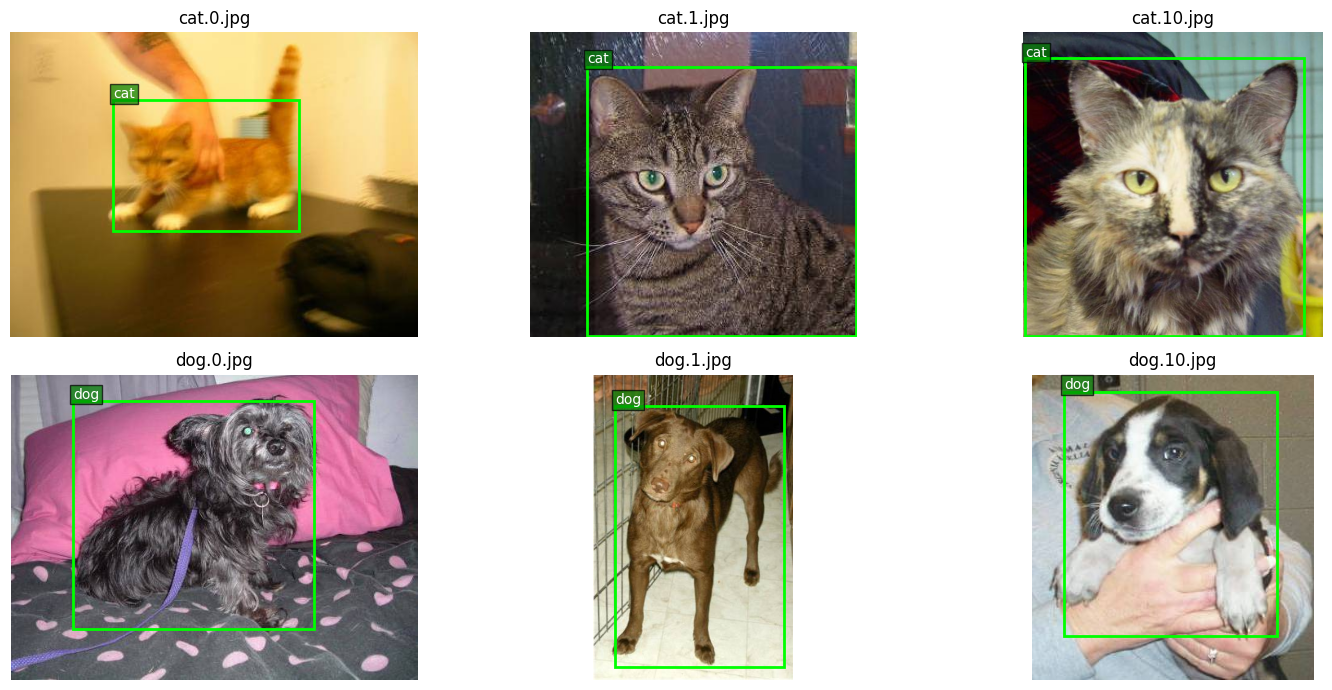

In [15]:
def show_dataset_examples(dataset, num_examples=6):
    fig, axes = plt.subplots(2, num_examples // 2, figsize=(15, 7))
    axes = np.asarray(axes).reshape(-1)
    shown = 0

    for wanted_label in (0, 1):
        for idx in range(len(dataset)):
            image, bbox, label = dataset[idx]
            if label != wanted_label:
                continue
            ax = axes[shown]
            img = image.permute(1, 2, 0).numpy()
            H, W = img.shape[:2]
            x1, y1, x2, y2 = bbox['xmin'], bbox['ymin'], bbox['xmax'], bbox['ymax']
            if dataset.return_scaled:
                x1, x2 = x1 * W, x2 * W
                y1, y2 = y1 * H, y2 * H
            ax.imshow(np.clip(img, 0, 1))
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                           fill=False, edgecolor='lime', linewidth=2))
            ax.text(x1, max(0, y1-3), ['cat', 'dog'][label], color='white',
                    bbox={'facecolor': 'green', 'alpha': 0.7, 'pad': 2})
            ax.set_title(dataset.samples[idx]['filename'])
            ax.axis('off')
            shown += 1
            if shown >= len(axes) or shown % (num_examples // 2) == 0:
                break
        if shown >= len(axes):
            break
    plt.tight_layout()
    plt.show()

show_dataset_examples(dataset)


In [16]:
def reversed_label_encoding(name):
    return 1 if str(name).lower() == 'cat' else 0

check_ds = AnimalDetectionDataset(
    root=DATA_DIR,
    transforms=transforms.Compose([transforms.Resize((128, 128)), transforms.ToTensor()]),
    target_transform=reversed_label_encoding,
    return_scaled=True,
)
_, _, transformed_label = check_ds[0]
print('Метка после пользовательского target_transform:', transformed_label)


Метка после пользовательского target_transform: 1


In [17]:
for i in range(min(5, len(dataset))):
    image, bbox, label = dataset[i]
    print(f"{i+1}. {dataset.samples[i]['filename']}: class={['cat','dog'][label]}, bbox={bbox}")


1. cat.0.jpg: class=cat, bbox={'xmin': 0.252, 'ymin': 0.22192513368983957, 'xmax': 0.708, 'ymax': 0.6497326203208557}
2. cat.1.jpg: class=cat, bbox={'xmin': 0.17333333333333334, 'ymin': 0.11071428571428571, 'xmax': 0.9966666666666667, 'ymax': 0.9928571428571429}
3. cat.10.jpg: class=cat, bbox={'xmin': 0.004983305931091309, 'ymin': 0.08466529846191406, 'xmax': 0.9383597373962402, 'ymax': 0.9929537773132324}
4. cat.11.jpg: class=cat, bbox={'xmin': 0.3287442922592163, 'ymin': 0.03590169548988342, 'xmax': 0.8390543460845947, 'ymax': 0.939247727394104}
5. cat.12.jpg: class=cat, bbox={'xmin': 0.12666666666666668, 'ymin': 0.08482142857142858, 'xmax': 0.8033333333333333, 'ymax': 0.8526785714285714}


<p class="task" id="3"></p>

3\. Создайте объект класса `AnimalDetectionDataset` без применения преобразований и со значением `return_scaled=False`. Напишите функцию `show_image_with_bounding_box` для визуализации изображения с добавлением на него bounding box и подписи объекта. Продемонстрируйте работу функцию на изображении собаки и кошки.

- [ ] Проверено на семинаре

In [18]:
raw_dataset = AnimalDetectionDataset(
    root=DATA_DIR,
    transforms=None,
    target_transform=encode_animal_label,
    return_scaled=False,
)
print('return_scaled =', raw_dataset.return_scaled)


return_scaled = False


In [19]:
def show_image_with_bounding_box(dataset, index, title=None):
    image_tensor, bbox, label = dataset[index]
    image = image_tensor.permute(1, 2, 0).numpy()

    x1, y1 = bbox['xmin'], bbox['ymin']
    x2, y2 = bbox['xmax'], bbox['ymax']
    H, W = image.shape[:2]
    if dataset.return_scaled:
        x1, x2 = x1 * W, x2 * W
        y1, y2 = y1 * H, y2 * H

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(np.clip(image, 0, 1))
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   fill=False, edgecolor='red', linewidth=3))
    ax.text(x1, max(0, y1-5), ['cat', 'dog'][label], color='white',
            bbox={'facecolor': 'red', 'alpha': 0.75, 'pad': 2})
    ax.set_title(title or f"{dataset.samples[index]['filename']} — {['cat','dog'][label]}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()


In [20]:
def find_first_index_by_label(dataset, wanted_label):
    for idx, sample in enumerate(dataset.samples):
        label_name = sample['obj_name']
        label = encode_animal_label(label_name)
        if label == wanted_label:
            return idx
    raise RuntimeError(f'Класс {wanted_label} не найден')

cat_idx = find_first_index_by_label(raw_dataset, 0)
dog_idx = find_first_index_by_label(raw_dataset, 1)
print('Кошка:', raw_dataset.samples[cat_idx]['filename'])
print('Собака:', raw_dataset.samples[dog_idx]['filename'])


Кошка: cat.0.jpg
Собака: dog.0.jpg


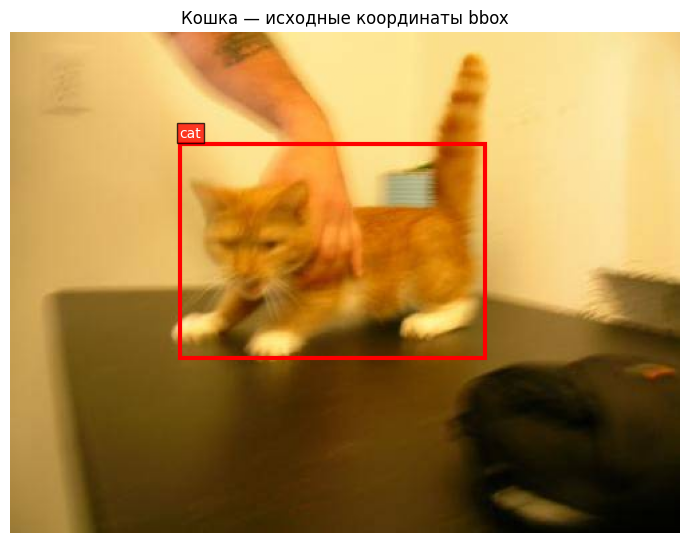

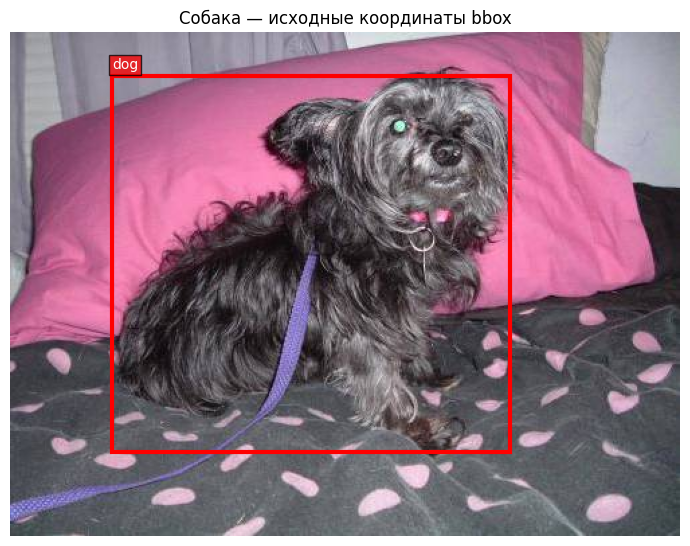

In [21]:
show_image_with_bounding_box(raw_dataset, cat_idx, 'Кошка — исходные координаты bbox')
show_image_with_bounding_box(raw_dataset, dog_idx, 'Собака — исходные координаты bbox')


<p class="task" id="4"></p>

4\. Напишите модель для решения задачи выделения объектов. Реализуйте двухголовую сеть, одна голова которой предсказывает метку объекта (задача классификации), а вторая голова предсказывает 4 координаты вершин bounding box (задача регрессии). В качестве backbone используйте модель resnet50 из пакета `torchvision`.

- [ ] Проверено на семинаре

In [22]:
class TwoHeadObjectDetectionModel(nn.Module):
    """ResNet50 backbone + две головы: class и normalized bbox."""
    def __init__(self, num_classes=2, pretrained=True, freeze_backbone=True):
        super().__init__()
        self.num_classes = num_classes
        self.freeze_backbone = bool(freeze_backbone)

        weights = ResNet50_Weights.DEFAULT if pretrained else None
        try:
            self.backbone = models.resnet50(weights=weights)
            self.pretrained_loaded = weights is not None
        except Exception as exc:
            warnings.warn(f'Не удалось загрузить pretrained ResNet50 ({exc}). Используются случайные веса.')
            self.backbone = models.resnet50(weights=None)
            self.pretrained_loaded = False

        feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Замораживать случайный backbone нельзя — тогда головы не смогут научиться полезным признакам.
        if self.freeze_backbone and self.pretrained_loaded:
            for p in self.backbone.parameters():
                p.requires_grad = False
        else:
            self.freeze_backbone = False

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 512), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        self.bbox_regressor = nn.Sequential(
            nn.Linear(feature_dim, 512), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(inplace=True),
            nn.Linear(256, 4), nn.Sigmoid(),
        )

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()  
        return self

    def forward(self, x):
        features = self.backbone(x)
        class_logits = self.classifier(features)
        raw_box = self.bbox_regressor(features)

        xy1 = torch.minimum(raw_box[:, :2], raw_box[:, 2:])
        xy2 = torch.maximum(raw_box[:, :2], raw_box[:, 2:])
        bbox = torch.cat([xy1, xy2], dim=1)
        return class_logits, bbox


In [23]:
# Совместимость с предыдущими ячейками/названиями.
SimpleObjectDetectionModel = TwoHeadObjectDetectionModel


In [24]:
class MultiTaskLoss(nn.Module):
    """Ровно сумма CrossEntropyLoss + MSELoss, как требуется в задании 5."""
    def __init__(self, classification_weight=1.0, regression_weight=1.0):
        super().__init__()
        self.classification_weight = classification_weight
        self.regression_weight = regression_weight
        self.classification_loss = nn.CrossEntropyLoss()
        self.regression_loss = nn.MSELoss()

    def forward(self, class_logits, bbox_pred, class_targets, bbox_targets):
        cls_loss = self.classification_loss(class_logits, class_targets)
        reg_loss = self.regression_loss(bbox_pred, bbox_targets)
        total = self.classification_weight * cls_loss + self.regression_weight * reg_loss
        return total, cls_loss, reg_loss


In [25]:
def create_model(num_classes=2, pretrained=True, freeze_backbone=True):
    return TwoHeadObjectDetectionModel(
        num_classes=num_classes,
        pretrained=pretrained,
        freeze_backbone=freeze_backbone,
    )


In [26]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [27]:
print('ДЕМОНСТРАЦИЯ ДВУХГОЛОВОЙ RESNET50')
model_demo = create_model(num_classes=2, pretrained=False, freeze_backbone=False)
test_input = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    class_logits, bbox_coords = model_demo(test_input)
print('input:', tuple(test_input.shape))
print('classification:', tuple(class_logits.shape))
print('bbox:', tuple(bbox_coords.shape))
print('bbox диапазон:', float(bbox_coords.min()), '...', float(bbox_coords.max()))

loss_fn = MultiTaskLoss()
class_targets = torch.tensor([0, 1])
bbox_targets = torch.tensor([[0.1, 0.1, 0.8, 0.7], [0.2, 0.3, 0.9, 0.8]], dtype=torch.float32)
total_loss, cls_loss, reg_loss = loss_fn(class_logits, bbox_coords, class_targets, bbox_targets)
print(f'CE={cls_loss.item():.4f}, MSE={reg_loss.item():.4f}, total={total_loss.item():.4f}')


ДЕМОНСТРАЦИЯ ДВУХГОЛОВОЙ RESNET50
input: (2, 3, 224, 224)
classification: (2, 2)
bbox: (2, 4)
bbox диапазон: 0.47565868496894836 ... 0.5563853979110718
CE=0.6929, MSE=0.0926, total=0.7855


<p class="task" id="5"></p>

5\. Разбейте набор данных на обучающее и валидационное множество. Обучите модель, описанную в задаче 4. При создании датасета не забудьте указать преобразования, соответствующие модели ResNet.

Используйте сумму MSELoss (для расчета ошибки на задаче регрессии) и CrossEntropyLoss (для расчета ошибки на задачи классификации) для настройки весов модели. Для ускорения процесса обучения слои backbone можно заморозить. Во время обучения выводите на экран значения функции потерь на обучающем и валидационном множестве. Используя обученную модель, получите предсказания для изображения кошки и собаки и отрисуйте их. Выполните процедуру, обратную нормализации, чтобы корректно отобразить фотографии.

- [ ] Проверено на семинаре

Исправлено конфликтующих XML-меток по имени файла: 2
device: cuda
train: 880 val: 220 batch: 16
Epoch 01/100 | train loss=0.1284 (CE=0.0991, MSE=0.0293) acc=0.976 IoU=0.595 | val loss=0.0317 (CE=0.0088, MSE=0.0229) acc=1.000 IoU=0.624
Epoch 02/100 | train loss=0.0351 (CE=0.0181, MSE=0.0170) acc=0.993 IoU=0.661 | val loss=0.0298 (CE=0.0147, MSE=0.0151) acc=0.991 IoU=0.662
Epoch 03/100 | train loss=0.0128 (CE=0.0022, MSE=0.0106) acc=1.000 IoU=0.701 | val loss=0.0206 (CE=0.0096, MSE=0.0110) acc=0.995 IoU=0.686
Epoch 04/100 | train loss=0.0082 (CE=0.0008, MSE=0.0074) acc=1.000 IoU=0.727 | val loss=0.0170 (CE=0.0070, MSE=0.0099) acc=0.995 IoU=0.697
Epoch 05/100 | train loss=0.0072 (CE=0.0006, MSE=0.0066) acc=1.000 IoU=0.734 | val loss=0.0151 (CE=0.0053, MSE=0.0098) acc=0.995 IoU=0.697
Epoch 06/100 | train loss=0.0064 (CE=0.0005, MSE=0.0059) acc=1.000 IoU=0.743 | val loss=0.0142 (CE=0.0049, MSE=0.0093) acc=0.995 IoU=0.689
Epoch 07/100 | train loss=0.0060 (CE=0.0004, MSE=0.0056) acc=1.000 IoU

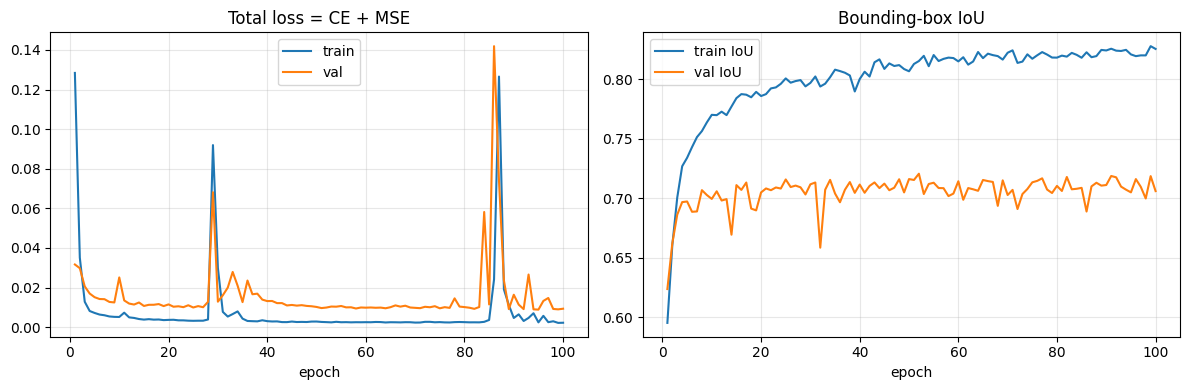

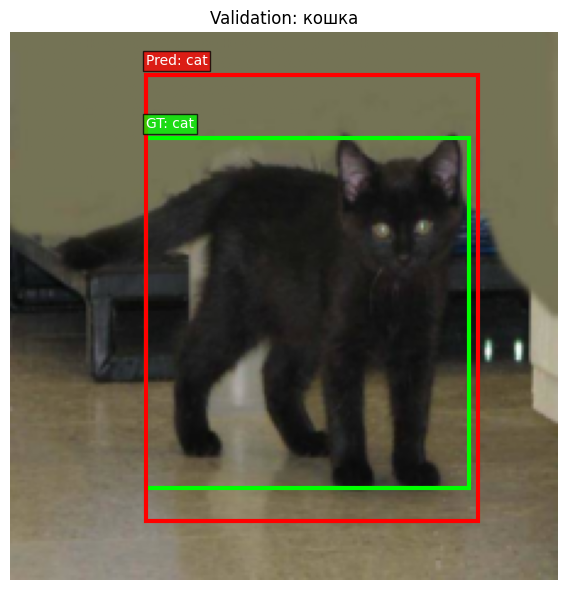

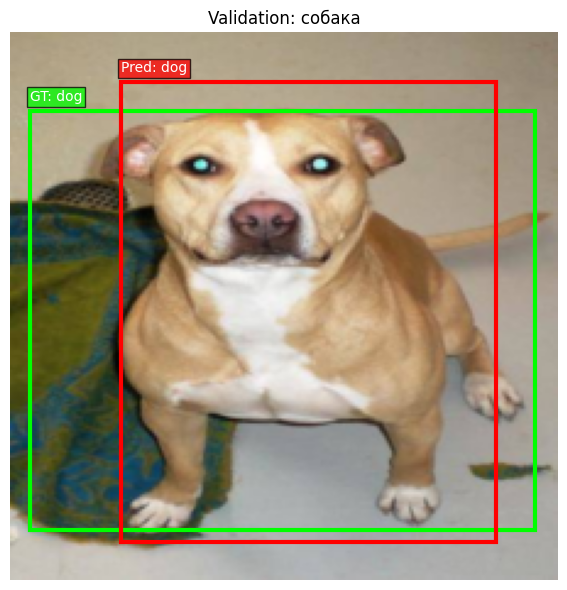

In [32]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

index_ds = AnimalDetectionDataset(
    DATA_DIR, transforms=None, target_transform=encode_animal_label, return_scaled=True
)
print('Исправлено конфликтующих XML-меток по имени файла:', len(index_ds.label_conflicts))
# Стратифицированный split: и в train, и в val гарантированно есть кошки и собаки.
rng = random.Random(SEED)
class_indices = {0: [], 1: []}
for idx, sample in enumerate(index_ds.samples):
    class_indices[encode_animal_label(sample['obj_name'])].append(idx)
train_indices, val_indices = [], []
for cls, cls_indices in class_indices.items():
    rng.shuffle(cls_indices)
    n_val = max(1, int(round(0.2 * len(cls_indices))))
    val_indices.extend(cls_indices[:n_val])
    train_indices.extend(cls_indices[n_val:])
rng.shuffle(train_indices); rng.shuffle(val_indices)

# Разные dataset-объекты, поэтому val transforms не перезаписывают train transforms.
train_base = AnimalDetectionDataset(
    DATA_DIR, transforms=train_tf, target_transform=encode_animal_label, return_scaled=True
)
val_base = AnimalDetectionDataset(
    DATA_DIR, transforms=val_tf, target_transform=encode_animal_label, return_scaled=True
)
train_ds = Subset(train_base, train_indices)
val_ds = Subset(val_base, val_indices)


def detection_collate(batch):
    images, bboxes, labels = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels, dtype=torch.long)
    boxes = torch.tensor([
        [b['xmin'], b['ymin'], b['xmax'], b['ymax']] for b in bboxes
    ], dtype=torch.float32)
    return images, labels, boxes

BATCH = 16 if DEVICE.type == 'cuda' else 8
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, collate_fn=detection_collate)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, collate_fn=detection_collate)

print('device:', DEVICE)
print('train:', len(train_ds), 'val:', len(val_ds), 'batch:', BATCH)

model = create_model(num_classes=2, pretrained=True, freeze_backbone=True).to(DEVICE)
criterion = MultiTaskLoss()
optimizer = torch.optim.Adam(
    (p for p in model.parameters() if p.requires_grad), lr=1e-3, weight_decay=1e-4
)


def box_iou_one_to_one(pred, target):
    x1 = torch.maximum(pred[:, 0], target[:, 0])
    y1 = torch.maximum(pred[:, 1], target[:, 1])
    x2 = torch.minimum(pred[:, 2], target[:, 2])
    y2 = torch.minimum(pred[:, 3], target[:, 3])
    inter = (x2-x1).clamp(min=0) * (y2-y1).clamp(min=0)
    area_p = (pred[:, 2]-pred[:, 0]).clamp(min=0) * (pred[:, 3]-pred[:, 1]).clamp(min=0)
    area_t = (target[:, 2]-target[:, 0]).clamp(min=0) * (target[:, 3]-target[:, 1]).clamp(min=0)
    return inter / (area_p + area_t - inter + 1e-8)


def run_epoch(loader, training):
    model.train(training)
    total_sum = cls_sum = reg_sum = 0.0
    correct = count = 0
    iou_sum = 0.0

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, labels, boxes in loader:
            images, labels, boxes = images.to(DEVICE), labels.to(DEVICE), boxes.to(DEVICE)
            if training:
                optimizer.zero_grad(set_to_none=True)

            logits, pred_boxes = model(images)
            total, cls_loss, reg_loss = criterion(logits, pred_boxes, labels, boxes)
            if training:
                total.backward()
                optimizer.step()

            bs = images.size(0)
            total_sum += total.item() * bs
            cls_sum += cls_loss.item() * bs
            reg_sum += reg_loss.item() * bs
            correct += (logits.argmax(1) == labels).sum().item()
            iou_sum += box_iou_one_to_one(pred_boxes.detach(), boxes).sum().item()
            count += bs

    return {
        'total': total_sum / count,
        'cls': cls_sum / count,
        'reg': reg_sum / count,
        'acc': correct / count,
        'iou': iou_sum / count,
    }

EPOCHS = 100
history = {'train': [], 'val': []}
best_val = float('inf')
checkpoint_path = 'best_twohead.pth'

for epoch in range(1, EPOCHS + 1):
    train_m = run_epoch(train_loader, training=True)
    val_m = run_epoch(val_loader, training=False)
    history['train'].append(train_m)
    history['val'].append(val_m)

    if val_m['total'] < best_val:
        best_val = val_m['total']
        torch.save(model.state_dict(), checkpoint_path)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss={train_m['total']:.4f} (CE={train_m['cls']:.4f}, MSE={train_m['reg']:.4f}) "
        f"acc={train_m['acc']:.3f} IoU={train_m['iou']:.3f} | "
        f"val loss={val_m['total']:.4f} (CE={val_m['cls']:.4f}, MSE={val_m['reg']:.4f}) "
        f"acc={val_m['acc']:.3f} IoU={val_m['iou']:.3f}"
    )

model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE, weights_only=True))
model.eval()
print('Лучший checkpoint:', checkpoint_path)

epochs = np.arange(1, len(history['train']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [m['total'] for m in history['train']], label='train')
axes[0].plot(epochs, [m['total'] for m in history['val']], label='val')
axes[0].set_title('Total loss = CE + MSE'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(epochs, [m['iou'] for m in history['train']], label='train IoU')
axes[1].plot(epochs, [m['iou'] for m in history['val']], label='val IoU')
axes[1].set_title('Bounding-box IoU'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


def denormalize_image(tensor):
    mean = torch.tensor(IMAGENET_MEAN, dtype=tensor.dtype, device=tensor.device)[:, None, None]
    std = torch.tensor(IMAGENET_STD, dtype=tensor.dtype, device=tensor.device)[:, None, None]
    return (tensor * std + mean).clamp(0, 1)


def show_model_prediction(ds, index, title=None):
    image, bbox, true_label = ds[index]
    gt_box = torch.tensor([bbox['xmin'], bbox['ymin'], bbox['xmax'], bbox['ymax']], dtype=torch.float32)
    with torch.no_grad():
        logits, pred_box = model(image.unsqueeze(0).to(DEVICE))
    pred_label = int(logits.argmax(1).item())
    pred_box = pred_box[0].cpu()

    img = denormalize_image(image).permute(1, 2, 0).cpu().numpy()
    H, W = img.shape[:2]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    for box, color, prefix, label in [
        (gt_box, 'lime', 'GT', true_label),
        (pred_box, 'red', 'Pred', pred_label),
    ]:
        x1, y1, x2, y2 = box.tolist()
        x1, x2 = x1 * W, x2 * W
        y1, y2 = y1 * H, y2 * H
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       fill=False, edgecolor=color, linewidth=3))
        ax.text(x1, max(0, y1-4), f"{prefix}: {['cat','dog'][label]}", color='white',
                bbox={'facecolor': color, 'alpha': .75, 'pad': 2})
    ax.set_title(title or str(index))
    ax.axis('off'); plt.tight_layout(); plt.show()


def find_example(ds, wanted_label):
    for i in range(len(ds)):
        _, _, label = ds[i]
        if label == wanted_label:
            return i
    raise RuntimeError('Нет примера нужного класса')

show_model_prediction(val_ds, find_example(val_ds, 0), 'Validation: кошка')
show_model_prediction(val_ds, find_example(val_ds, 1), 'Validation: собака')


In [29]:
# 🟧 - ошибка/всё плохо
# 🟩 - всё хорошо, обучающая выборка/результаты
# 🟪 - тестовая выборка/результаты
# 🟦 - валидационная выборка/результаты

<p class="task" id="6"></p>

6\. Найдите в сети несколько изображений котов и собак. Используя любой инструмент для разметки (например, [CVAT](https://www.cvat.ai/)), выделите котов и собак на изображениях. Вставьте скриншот экспортированного файла с разметкой. Используя полученные изображения, визуализируйте разметку и bounding boxes, полученные при помощи модели.

- [ ] Проверено на семинаре

Мой Pascal VOC export: /home/crazy/work/labs/cat_and_dogs (1).zip
Архив с моими изображениями: /home/crazy/work/labs/Cat_and_dogs.zip
XML-аннотаций: 10
Найдено соответствующих JPG: 10
Количество объектов по XML: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


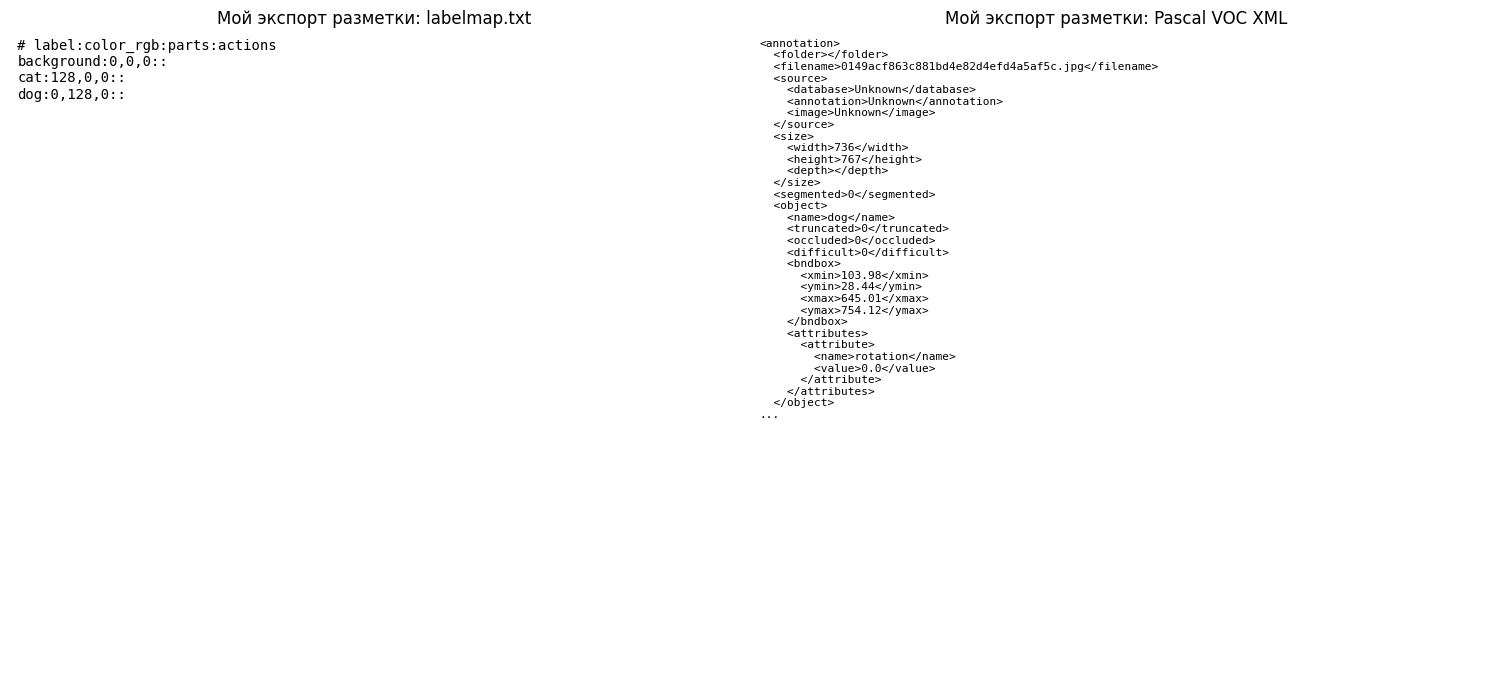

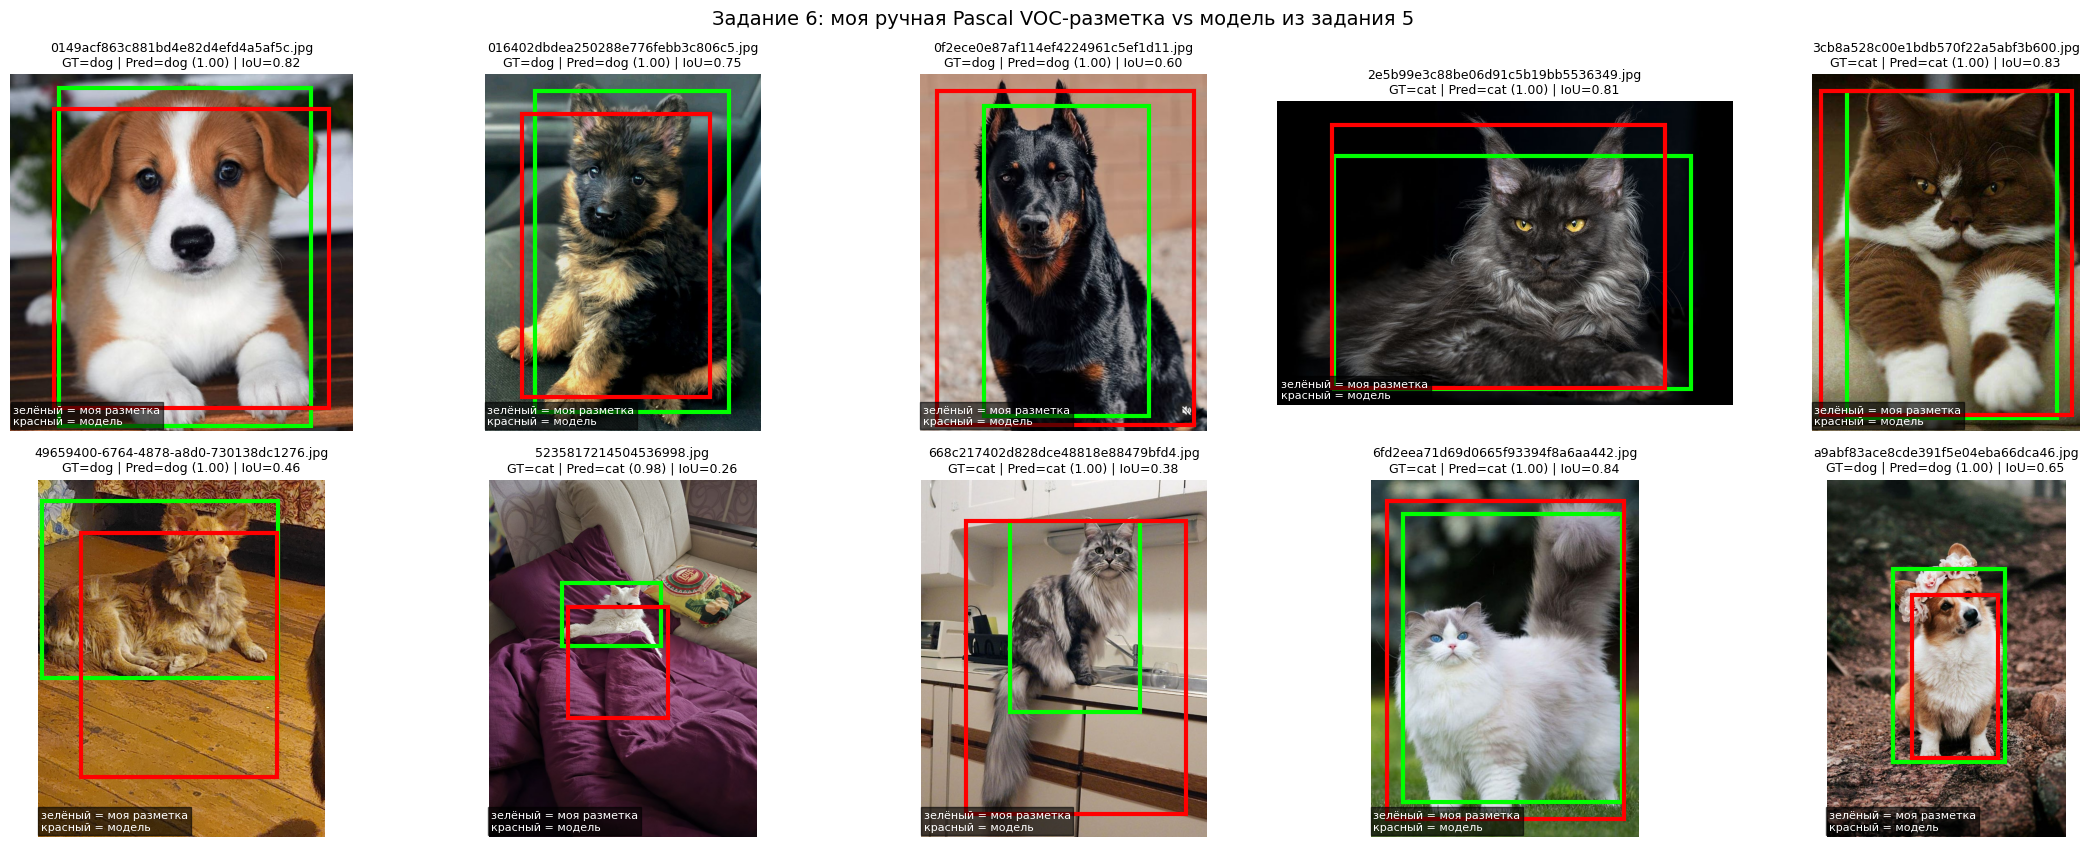

In [30]:
from io import BytesIO


def _candidate_zip_paths():
    """Небольшой безопасный поиск ZIP рядом с notebook и в labs/."""
    candidates = []
    for root in (Path.cwd(), Path('labs')):
        if root.exists():
            candidates.extend(sorted(root.glob('*.zip')))
    out, seen = [], set()
    for p in candidates:
        try:
            rp = p.resolve()
        except Exception:
            continue
        if rp not in seen and rp.is_file():
            seen.add(rp)
            out.append(rp)
    return out


def _voc_xml_names(zf):
    return sorted(
        n for n in zf.namelist()
        if n.lower().startswith('annotations/') and n.lower().endswith('.xml')
    )


def _image_members(zf):
    return {
        Path(n).name: n
        for n in zf.namelist()
        if n.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
        and not n.endswith('/')
    }


def find_manual_annotation_and_image_zips():
    """Находит Pascal VOC export и отдельный ZIP с соответствующими JPG."""
    zips = _candidate_zip_paths()
    annotation_candidates = []

    for path in zips:
        try:
            with zipfile.ZipFile(path, 'r') as zf:
                xml_names = _voc_xml_names(zf)
                if xml_names:
                    annotation_candidates.append((path, len(xml_names)))
        except zipfile.BadZipFile:
            pass

    if not annotation_candidates:
        raise FileNotFoundError(
            'Не найден Pascal VOC export с Annotations/*.xml. '
            'Положите cat_and_dogs*.zip рядом с notebook.'
        )

    annotation_zip = max(annotation_candidates, key=lambda x: x[1])[0]

    with zipfile.ZipFile(annotation_zip, 'r') as zf:
        xml_names = _voc_xml_names(zf)
        expected = []
        for xml_name in xml_names:
            root = _xml_root(zf.read(xml_name))
            filename = (root.findtext('filename') or '').strip()
            if filename:
                expected.append(Path(filename).name)

    expected_set = set(expected)
    best_image_zip, best_matches = None, -1
    for path in zips:
        if path == annotation_zip:
            continue
        try:
            with zipfile.ZipFile(path, 'r') as zf:
                image_map = _image_members(zf)
                matches = len(expected_set.intersection(image_map))
            if matches > best_matches:
                best_image_zip, best_matches = path, matches
        except zipfile.BadZipFile:
            pass

    if best_image_zip is None or best_matches == 0:
        raise FileNotFoundError(
            'Не найден отдельный ZIP с JPG, имена которых совпадают с <filename> '
        )

    return annotation_zip, best_image_zip, expected


def show_manual_export_screenshot(annotation_zip):
    """Показывает содержимое ручного Pascal VOC export как отдельную визуализацию."""
    with zipfile.ZipFile(annotation_zip, 'r') as zf:
        xml_names = _voc_xml_names(zf)
        names = zf.namelist()
        labelmap_name = next((n for n in names if n.lower().endswith('labelmap.txt')), None)
        labelmap = (
            zf.read(labelmap_name).decode('utf-8', errors='replace')
            if labelmap_name else '(labelmap.txt отсутствует)'
        )
        first_xml = (
            zf.read(xml_names[0]).decode('utf-8', errors='replace')
            if xml_names else '(XML отсутствуют)'
        )

    def trim(text, max_lines=32):
        lines = text.replace('\t', '    ').splitlines()
        return '\n'.join(lines[:max_lines]) + ('\n...' if len(lines) > max_lines else '')

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    for ax in axes:
        ax.axis('off')
    axes[0].text(0.01, 0.99, trim(labelmap), va='top', family='monospace', fontsize=10)
    axes[0].set_title('Мой экспорт разметки: labelmap.txt')
    axes[1].text(0.01, 0.99, trim(first_xml), va='top', family='monospace', fontsize=8)
    axes[1].set_title('Мой экспорт разметки: Pascal VOC XML')
    plt.tight_layout()
    plt.show()


def load_manual_pairs_from_two_zips(annotation_zip, image_zip):
    """Связывает XML и JPG строго по <filename>, не извлекая архивы на диск."""
    pairs, missing = [], []

    with zipfile.ZipFile(annotation_zip, 'r') as za, zipfile.ZipFile(image_zip, 'r') as zi:
        image_map = _image_members(zi)
        for xml_name in _voc_xml_names(za):
            xml_bytes = za.read(xml_name)
            root = _xml_root(xml_bytes)
            filename = Path((root.findtext('filename') or '').strip()).name
            if not filename:
                continue

            member = image_map.get(filename)
            if member is None:
                missing.append(filename)
                continue

            image_bytes = zi.read(member)
            ann = parse_xml(xml_bytes)
            n_objects = len(root.findall('object'))

            pairs.append({
                'filename': filename,
                'xml_name': xml_name,
                'xml_bytes': xml_bytes,
                'image_bytes': image_bytes,
                'annotation': ann,
                'n_objects': n_objects,
            })

    return pairs, missing


def predict_manual_image(pil_image):
    inp = val_tf(pil_image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits, pred_box = model(inp)
        probs = torch.softmax(logits, dim=1)
    pred_label = int(probs.argmax(1).item())
    pred_conf = float(probs[0, pred_label].item())
    return pred_label, pred_conf, pred_box[0].cpu()


def show_manual_annotation_results(pairs, max_images=10):
    n = min(max_images, len(pairs))
    if n == 0:
        print('Нет доступных пар JPG + XML в пользовательских архивах.')
        return

    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.3 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')

    for ax, item in zip(axes, pairs[:n]):
        pil = Image.open(BytesIO(item['image_bytes'])).convert('RGB')
        W, H = pil.size
        ann = item['annotation']
        gt_name = ann['obj_name']
        gt_label = encode_animal_label(gt_name)
        gt = ann['raw']

        pred_label, pred_conf, pred_box = predict_manual_image(pil)
        gt_scaled = torch.tensor([[
            float(gt['xmin']) / W, float(gt['ymin']) / H,
            float(gt['xmax']) / W, float(gt['ymax']) / H,
        ]], dtype=torch.float32)
        iou = float(box_iou_one_to_one(pred_box.unsqueeze(0), gt_scaled)[0].item())

        ax.imshow(pil)

        gx1, gy1 = float(gt['xmin']), float(gt['ymin'])
        gx2, gy2 = float(gt['xmax']), float(gt['ymax'])
        ax.add_patch(patches.Rectangle(
            (gx1, gy1), gx2-gx1, gy2-gy1,
            fill=False, edgecolor='lime', linewidth=3,
        ))

        px1, py1, px2, py2 = pred_box.numpy() * np.array([W, H, W, H], dtype=np.float32)
        ax.add_patch(patches.Rectangle(
            (px1, py1), px2-px1, py2-py1,
            fill=False, edgecolor='red', linewidth=3,
        ))

        ax.set_title(
            f"{item['filename']}\n"
            f"GT={gt_name} | Pred={['cat','dog'][pred_label]} ({pred_conf:.2f}) | IoU={iou:.2f}",
            fontsize=9,
        )
        ax.text(
            0.01, 0.02,
            'зелёный = моя разметка\nкрасный = модель',
            transform=ax.transAxes, color='white', fontsize=8,
            bbox={'facecolor':'black','alpha':0.6,'pad':2},
        )
        ax.axis('off')

    fig.suptitle(
        'Задание 6: моя ручная Pascal VOC-разметка vs модель из задания 5',
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


manual_annotation_zip, manual_image_zip, expected_manual_names = find_manual_annotation_and_image_zips()
print('Мой Pascal VOC export:', manual_annotation_zip)
print('Архив с моими изображениями:', manual_image_zip)

manual_pairs, missing_manual_images = load_manual_pairs_from_two_zips(
    manual_annotation_zip, manual_image_zip
)
print('XML-аннотаций:', len(expected_manual_names))
print('Найдено соответствующих JPG:', len(manual_pairs))
print('Количество объектов по XML:', [p['n_objects'] for p in manual_pairs])

if missing_manual_images:
    print('Не найдены изображения:', missing_manual_images)

show_manual_export_screenshot(manual_annotation_zip)
show_manual_annotation_results(manual_pairs, max_images=10)


Анализ validation:   0%|          | 0/220 [00:00<?, ?it/s]

Однообъектных validation-примеров: 207
Ошибок классификации: 0
Средний IoU: 0.7261
Минимальный IoU: 0.1901

Архитектурное ограничение: TwoHeadResNet50 предсказывает ровно один bbox. Если на фотографии несколько кошек/собак, модель не обязана находить их все — для этого нужна настоящая multi-object архитектура (например Faster R-CNN/YOLO).
Реальные ошибки классификации однообъектной модели: примеров нет.


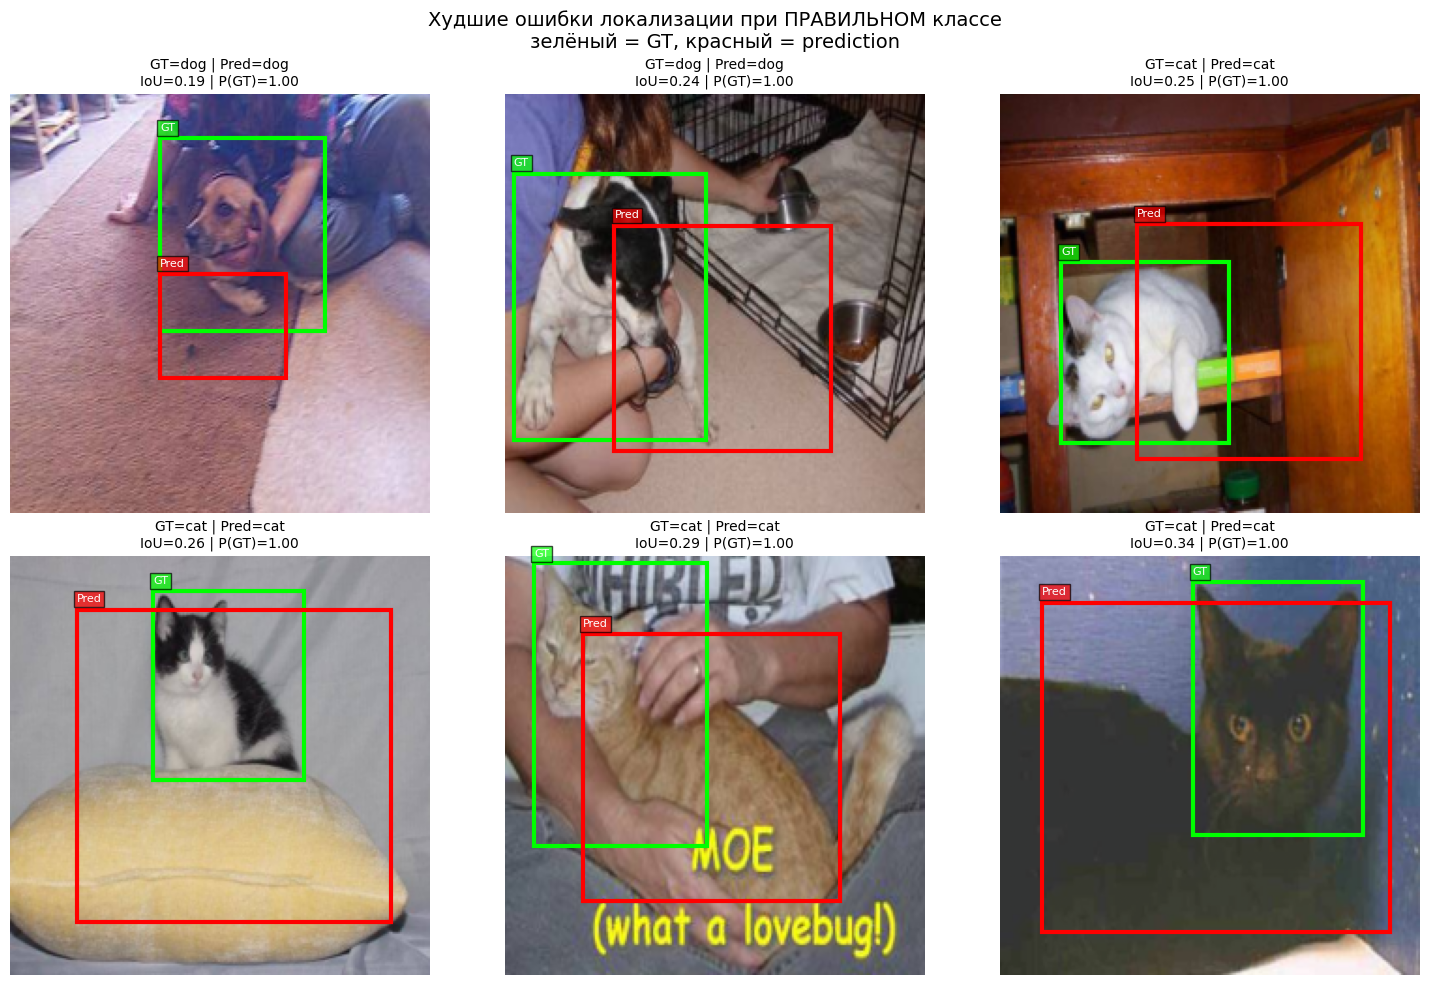

In [31]:
# Плохие предсказания на большом Asirra-наборе.
# Модель — ОДНООБЪЕКТНАЯ.
# Её выходы имеют формы:
#   class_logits: [B, 2]
#   bbox:         [B, 4]
# Поэтому она физически может вернуть только ОДИН bbox на изображение.
# Сцены с несколькими животными — это ограничение постановки/архитектуры,
# а не отдельная ошибка реализации.
# Ниже "плохие примеры" ранжируются только относительно ЕДИНСТВЕННОГО
# GT bbox из Pascal VOC XML большого Asirra-набора.


def _resolve_subset_sample(ds, local_idx):
    if isinstance(ds, Subset):
        base_idx = ds.indices[local_idx]
        return ds.dataset, base_idx
    return ds, local_idx


def _xml_object_count_for_sample(ds, local_idx):
    base_ds, base_idx = _resolve_subset_sample(ds, local_idx)
    sample = base_ds.samples[base_idx]
    root = _xml_root(sample['xml_path'])
    return len(root.findall('object'))


def collect_validation_errors(ds):
    results = []
    model.eval()

    with torch.no_grad():
        for local_idx in tqdm(range(len(ds)), desc='Анализ validation'):
            n_objects = _xml_object_count_for_sample(ds, local_idx)
            if n_objects != 1:
                continue

            image, bbox, true_label = ds[local_idx]
            gt_box = torch.tensor(
                [bbox['xmin'], bbox['ymin'], bbox['xmax'], bbox['ymax']],
                dtype=torch.float32,
            )

            logits, pred_box = model(image.unsqueeze(0).to(DEVICE))
            probs = torch.softmax(logits, dim=1)[0].cpu()
            pred_label = int(probs.argmax().item())
            pred_box = pred_box[0].cpu()

            iou = float(
                box_iou_one_to_one(
                    pred_box.unsqueeze(0), gt_box.unsqueeze(0)
                )[0].item()
            )
            true_prob = float(probs[int(true_label)].item())
            class_error = int(pred_label != int(true_label))

            results.append({
                'local_idx': local_idx,
                'image': image.cpu(),
                'gt_box': gt_box,
                'pred_box': pred_box,
                'true_label': int(true_label),
                'pred_label': pred_label,
                'true_prob': true_prob,
                'iou': iou,
                'class_error': class_error,
            })

    return results


def _plot_error_examples(items, title, n=6):
    items = items[:min(n, len(items))]
    if not items:
        print(f'{title}: примеров нет.')
        return

    cols = 3
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')

    for ax, item in zip(axes, items):
        img = denormalize_image(item['image']).permute(1, 2, 0).numpy()
        H, W = img.shape[:2]
        ax.imshow(img)

        for box, color, name in [
            (item['gt_box'], 'lime', 'GT'),
            (item['pred_box'], 'red', 'Pred'),
        ]:
            x1, y1, x2, y2 = box.tolist()
            x1, x2 = x1 * W, x2 * W
            y1, y2 = y1 * H, y2 * H
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                fill=False, edgecolor=color, linewidth=3,
            ))
            ax.text(
                x1, max(0, y1-4), name,
                color='white', fontsize=8,
                bbox={'facecolor':color,'alpha':0.7,'pad':2},
            )

        ax.set_title(
            f"GT={['cat','dog'][item['true_label']]} | "
            f"Pred={['cat','dog'][item['pred_label']]}\n"
            f"IoU={item['iou']:.2f} | P(GT)={item['true_prob']:.2f}",
            fontsize=10,
        )
        ax.axis('off')

    fig.suptitle(title + '\nзелёный = GT, красный = prediction', fontsize=14)
    plt.tight_layout()
    plt.show()


validation_errors = collect_validation_errors(val_ds)

classification_errors = sorted(
    [x for x in validation_errors if x['class_error'] == 1],
    key=lambda x: x['true_prob']
)
localization_errors = sorted(
    [x for x in validation_errors if x['class_error'] == 0],
    key=lambda x: x['iou']
)

ious = np.array([x['iou'] for x in validation_errors], dtype=float)
print('Однообъектных validation-примеров:', len(validation_errors))
print('Ошибок классификации:', len(classification_errors))
print('Средний IoU:', round(float(ious.mean()), 4) if len(ious) else '—')
print('Минимальный IoU:', round(float(ious.min()), 4) if len(ious) else '—')
print()
print(
    'Архитектурное ограничение: TwoHeadResNet50 предсказывает ровно один bbox. '
    'Если на фотографии несколько кошек/собак, модель не обязана находить их все — '
    'для этого нужна настоящая multi-object архитектура (например Faster R-CNN/YOLO).'
)

_plot_error_examples(
    classification_errors,
    'Реальные ошибки классификации однообъектной модели',
    n=6,
)

_plot_error_examples(
    localization_errors,
    'Худшие ошибки локализации при ПРАВИЛЬНОМ классе',
    n=6,
)


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ